## Assignment 2: Momentum and cross-section of returns
### 15.458 Quantitative Investment Management - Spring 2026
### Arturo Favara 

### 0 Setup: load data.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("SP500Raw.xlsx") 
df = pd.read_excel(DATA_PATH, engine="openpyxl")
df = df.rename(columns={c: str(c).strip().lower() for c in df.columns})
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ["permno", "price", "shrout", "prc", "mcap"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.sort_values(["permno", "date"]).reset_index(drop=True)
print(df.shape)
df

(90525, 6)


,permno,date,price,shrout,prc,mcap
0,10104,2010-01-29,23.06000,5011220,-0.057888,1.155587e+08
1,10104,2010-02-26,24.65000,5015000,0.068951,1.236198e+08
2,10104,2010-03-31,25.71000,5019091,0.043002,1.290408e+08
3,10104,2010-04-30,25.86750,5029523,0.008071,1.301012e+08
4,10104,2010-05-28,22.57000,5026000,-0.127477,1.134368e+08
...,...,...,...,...,...,...
90520,93436,2024-08-30,214.11000,3194640,-0.077391,6.840044e+08
90521,93436,2024-09-30,261.63000,3207000,0.221942,8.390474e+08
90522,93436,2024-10-31,249.85001,3210060,-0.045025,8.020335e+08
90523,93436,2024-11-29,345.16000,3210060,0.381469,1.107984e+09


Helpers: returns, percentiles, Fama-MacBeth (used below).

In [28]:
import statsmodels.api as sm
from scipy import stats as _scipy_stats

def _rolling_prod_minus_one(s, w):
    return (1 + s).rolling(w, min_periods=w).apply(lambda x: x.prod() - 1, raw=True)

def build_full_panel(df):
    out = df.sort_values(["permno", "date"]).copy()
    g = out.groupby("permno", group_keys=False)
    out["Price_Ret_T1"] = g["price"].pct_change()
    out["PRC_Ret_T12"] = g["prc"].transform(lambda x: _rolling_prod_minus_one(x, 12))
    out["Prices_Ret_T12"] = g["Price_Ret_T1"].transform(lambda x: _rolling_prod_minus_one(x, 12))
    out["PRC_Ret_T12M1"] = g["prc"].transform(lambda x: (1+x).shift(1).rolling(11, min_periods=11).apply(lambda y: np.prod(y)-1, raw=True))
    out["Prices_Ret_T12M1"] = g["Price_Ret_T1"].transform(lambda x: (1+x).shift(1).rolling(11, min_periods=11).apply(lambda y: np.prod(y)-1, raw=True))
    out["PRC_Ret_T12_1M"] = g["prc"].shift(12)
    out["Prices_Ret_T12_1M"] = g["Price_Ret_T1"].shift(12)
    out["Vol_Prices_Ret_T12M1"] = g["Price_Ret_T1"].transform(lambda x: x.shift(1).rolling(11, min_periods=11).std())
    out["SR_Prices_Ret_T12M1"] = out["Prices_Ret_T12M1"] / out["Vol_Prices_Ret_T12M1"]
    out.loc[out["Vol_Prices_Ret_T12M1"] <= 0, "SR_Prices_Ret_T12M1"] = np.nan
    out["PRC_Ret_F1M"] = g["prc"].shift(-1)
    out["PRC_Ret_F3M"] = g["prc"].transform(lambda x: (1+x.shift(-1))*(1+x.shift(-2))*(1+x.shift(-3))-1)
    out["PRC_Ret_F6M"] = g["prc"].transform(lambda x: (1+x.shift(-1))*(1+x.shift(-2))*(1+x.shift(-3))*(1+x.shift(-4))*(1+x.shift(-5))*(1+x.shift(-6))-1)
    out["log_mcap"] = np.log(out["mcap"].clip(lower=1e-6))
    return out

PCT_QUANT = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1]
PCT_LABELS = ["min", "p5", "p25", "median", "p75", "p95", "max"]
def percentile_series_by_date(df, value_col, date_col="date"):
    out = df.groupby(date_col)[value_col].quantile(PCT_QUANT).unstack()
    out.columns = PCT_LABELS
    return out
def median_of_percentiles(series_by_date):
    return series_by_date.median()
def panel_entry_exit_dates(df, date_col="date"):
    a = df.groupby("permno")[date_col].agg(["min", "max"]).rename(columns={"min": "first_date", "max": "last_date"})
    return a.reset_index()
def subset_month_before_exit(df, entry_exit, date_col="date"):
    m = df.merge(entry_exit[["permno", "last_date"]], on="permno")
    m["prev"] = m["last_date"] - pd.DateOffset(months=1)
    return m[m[date_col] == m["prev"]].drop(columns=["last_date", "prev"], errors="ignore")
def subset_month_of_entry(df, entry_exit, date_col="date"):
    m = df.merge(entry_exit[["permno", "first_date"]], on="permno")
    return m[m[date_col] == m["first_date"]].drop(columns=["first_date"], errors="ignore")
def percentile_set_cross_section(df, value_col):
    s = df[value_col].quantile(PCT_QUANT)
    s.index = PCT_LABELS
    return s

def cross_sectional_ols(y, X, weights=None):
    valid = y.notna() & X.notna().all(axis=1)
    y_, X_ = y.loc[valid].values, X.loc[valid].values
    w = weights.loc[valid].values.astype(float) if weights is not None else None
    n = len(y_)
    if n < 2: return {"coef": pd.Series(index=X.columns, dtype=float), "r_squared": np.nan}
    Xc = np.column_stack([np.ones(n), X_])
    mod = sm.WLS(y_, Xc, weights=w, hasconst=True) if w is not None else sm.OLS(y_, Xc, hasconst=True)
    res = mod.fit()
    return {"coef": pd.Series(res.params[1:], index=X.columns), "r_squared": res.rsquared}
def run_fama_macbeth(panel, y_col, x_cols, weight_col=None, date_col="date", min_obs=30):
    rows = []
    for date, g in panel.groupby(date_col):
        y, X = g[y_col], g[x_cols]
        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < min_obs: continue
        w = g[weight_col] if weight_col and weight_col in g.columns else None
        r = cross_sectional_ols(y, X, w)
        rows.append({**r["coef"], "_date": date})
    return pd.DataFrame(rows).set_index("_date") if rows else pd.DataFrame(columns=x_cols)
def fama_macbeth_inference(coef_series):
    c = coef_series.dropna()
    T = len(c)
    if T == 0: return {"mean": np.nan, "t_stat": np.nan, "p_value": np.nan}
    mean, se = c.mean(), c.std() / np.sqrt(T) if T > 1 else np.nan
    t = mean / se if se and se > 0 else np.nan
    p = 2 * (1 - _scipy_stats.t.cdf(abs(t), T - 1)) if _scipy_stats and T > 1 else np.nan
    return {"mean": mean, "t_stat": t, "p_value": p, "n_dates": T, "std_err": se}
def newey_west_t_stat(coef_series, max_lags=6):
    c = coef_series.dropna()
    T, mean = len(c), c.mean()
    if T == 0: return {"mean": np.nan, "t_stat": np.nan, "p_value": np.nan}
    max_lags = min(max_lags, T // 2)
    d = c - mean
    var = (d**2).mean() / T
    for L in range(1, max_lags + 1):
        if L < T: var += 2 * (1 - L/(max_lags+1)) * (d.iloc[:-L].values * d.iloc[L:].values).mean() / T
    se = np.sqrt(max(var, 0))
    t = mean / se if se > 0 else np.nan
    p = 2 * (1 - _scipy_stats.t.cdf(abs(t), T - 1)) if _scipy_stats else np.nan
    return {"mean": mean, "t_stat": t, "p_value": p}
def strategy_metrics(coef_series):
    c = coef_series.dropna()
    if len(c) == 0: return {"hit_rate": np.nan, "max_drawdown": np.nan, "sortino": np.nan}
    cum = (1 + c).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax().replace(0, np.nan)
    down = c[c < 0]
    sortino = c.mean() / np.sqrt((down**2).mean()) if len(down) > 0 else np.nan
    return {"hit_rate": (c > 0).mean(), "max_drawdown": dd.min(), "sortino": sortino}

print("Helpers defined.")

Helpers defined.


**2.** For many of the Companies, the one month percent change in price is not always equal to the PRC column.
- **(a)** Is this a data error or is this correct? Explain.

In [29]:
df["Price_Ret_T1"] = df.groupby("permno")["price"].pct_change()
diff = (df["Price_Ret_T1"] - df["prc"]).abs()
equal = (diff < 0.0001) & df["Price_Ret_T1"].notna() & df["prc"].notna()
n_equal, n_diff = equal.sum(), ((diff >= 0.0001) & df["Price_Ret_T1"].notna() & df["prc"].notna()).sum()
by_p = df.groupby("permno", group_keys=False).apply(
    lambda g: ((g["Price_Ret_T1"] - g["prc"]).abs() < 0.0001).all()
    if g["Price_Ret_T1"].notna().any() and g["prc"].notna().any() else False, include_groups=False)
n_always_equal = by_p[by_p].index.size
print("Rows equal (within 0.0001):", n_equal, "| different:", n_diff)
print("Permnos with Price_Ret_T1 == PRC for all dates:", n_always_equal)

Rows equal (within 0.0001): 65599 | different: 24123
Permnos with Price_Ret_T1 == PRC for all dates: 0


- **(b)** Why for some companies, the columns are always equal. Why?

Note when you calculate this for each company on each date, save this variable as we will be using it frequently. We refer to it as Price_Ret(T1).

In [30]:
# For each company, check if Price_Ret_T1 is always equal to prc
def always_equal(g):
    m = g['Price_Ret_T1'].notna() & g['prc'].notna()
    if m.sum() == 0:
        return False
    return (g.loc[m, 'Price_Ret_T1'] - g.loc[m, 'prc']).abs().max() < 0.0001

by_p = df.groupby("permno", group_keys=False).apply(always_equal, include_groups=False)
n_always_equal = by_p[by_p].index.size
n_not_always_equal = (~by_p).sum()
tot_n_firms = by_p.index.size
print(f"(b) Companies with Price_Ret_T1 not always equal to PRC: {n_not_always_equal} = {n_not_always_equal/tot_n_firms:.2%}")

(b) Companies with Price_Ret_T1 not always equal to PRC: 664 = 83.52%


**3.** For each date count the number of companies that exist. Why is not always 500? Is this a mistake? Explain.

0th percentile: 500
25th percentile: 500
50th percentile: 503
75th percentile: 505
100th percentile: 506


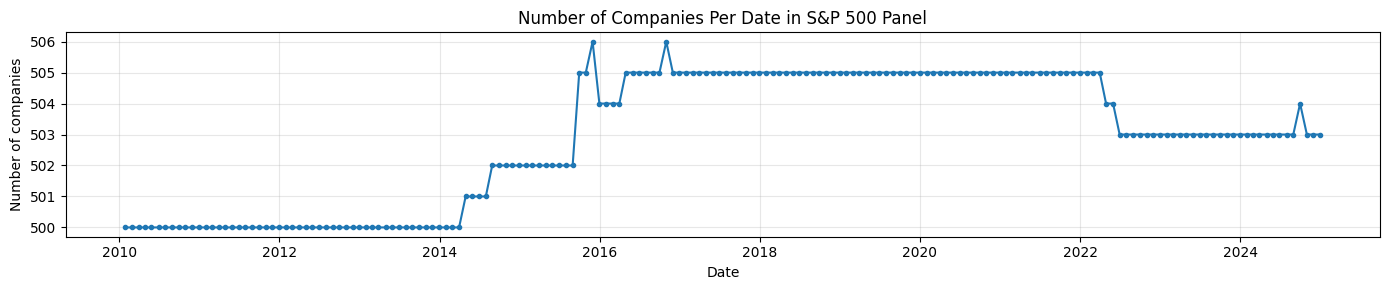

In [31]:
n_per_date = df.groupby("date").size()
percentiles = [0, 25, 50, 75, 100]
percentile_vals = np.percentile(n_per_date, percentiles)
for p, v in zip(percentiles, percentile_vals):
    print(f"{p}th percentile: {int(v)}")

# Plot companies per date
plt.figure(figsize=(14, 3))
plt.plot(n_per_date.index, n_per_date.values, marker='.', linestyle='-')
plt.title("Number of Companies Per Date in S&P 500 Panel")
plt.xlabel("Date")
plt.ylabel("Number of companies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**4.** How many of the companies are present over the entire sample? How many unique companies are in the sample?

In [32]:
n_dates = df["date"].nunique()
full_sample = df.groupby("permno")["date"].nunique()
full_sample = (full_sample >= n_dates).sum()
print("Unique companies (PERMNOs):", df["permno"].nunique())
print("Present in every month (full sample):", full_sample)

Unique companies (PERMNOs): 795
Present in every month (full sample): 285


**5.** Plot the time series of the max, 95th percentile, 75th percentile, median, 25th percentile, 5th percentile and min market cap of all stocks for each month, over the entire sample period.
- **(a)** Calculate the above percentile ranges for the market cap of the stocks the month prior to their leaving sample.

Note this set of percentiles as the "Percentile Sets" going forward.

In [33]:
pct_labels = ['min','p5','p25','median','p75','p95','max']
pct_values = [0,5,25,50,75,95,100]

def calc_percentiles(group, col='mcap'):
    v = group[col].dropna()
    if len(v) == 0: return pd.Series([np.nan]*7, index=pct_labels)
    return pd.Series(np.percentile(v, pct_values), index=pct_labels)

def plot_percentiles(pct_df, title, ylabel='', log_scale=False):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['red','orange','green','blue','green','orange','red']
    styles = ['--','--','-','-','-','--','--']
    for col_name, c, s in zip(pct_labels, colors, styles):
        ax.plot(pct_df.index, pct_df[col_name], label=col_name, color=c, linestyle=s)
    if log_scale: ax.set_yscale('log')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(ncol=7, loc='upper left')
    plt.tight_layout(); plt.show()

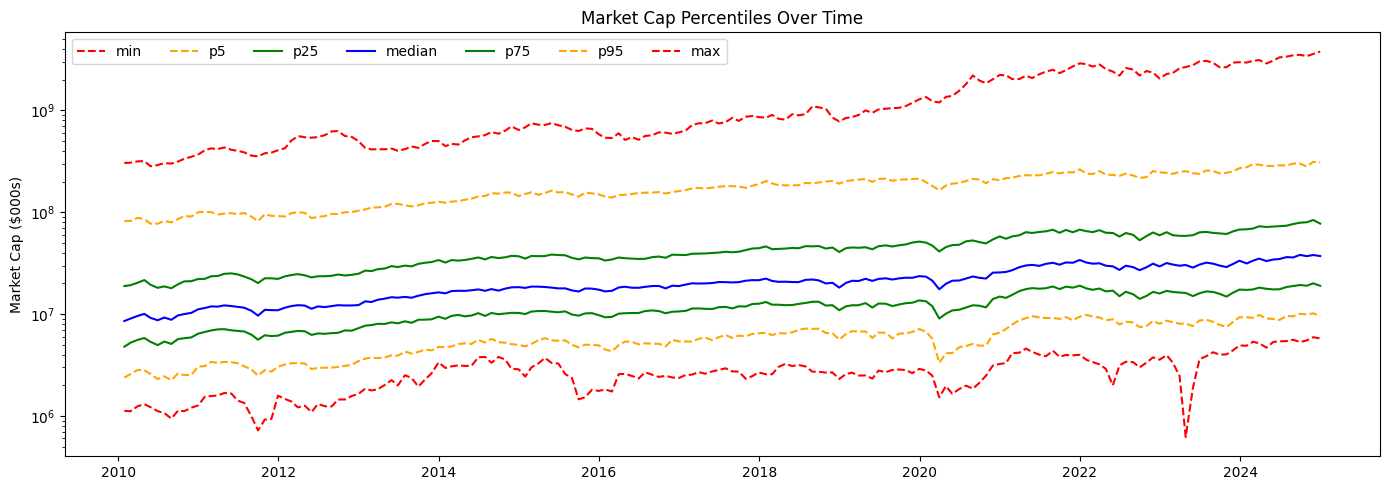

Median of each percentile time-series (Market Cap, $000s):


min       2.623974e+06
p5        5.545501e+06
p25       1.111962e+07
median    2.000460e+07
p75       4.032531e+07
p95       1.741709e+08
max       7.742933e+08
dtype: float64

In [34]:
# 5 — Main: Market cap percentiles over time
mcap_pcts = df.groupby('date').apply(calc_percentiles)
plot_percentiles(mcap_pcts, 'Market Cap Percentiles Over Time', 'Market Cap ($000s)', log_scale=True)

print("Median of each percentile time-series (Market Cap, $000s):")
display(mcap_pcts.median())

- **(b)** Repeat the above for companies on the month they enter the sample and month before they exit the sample


Total company-exit observations: 301


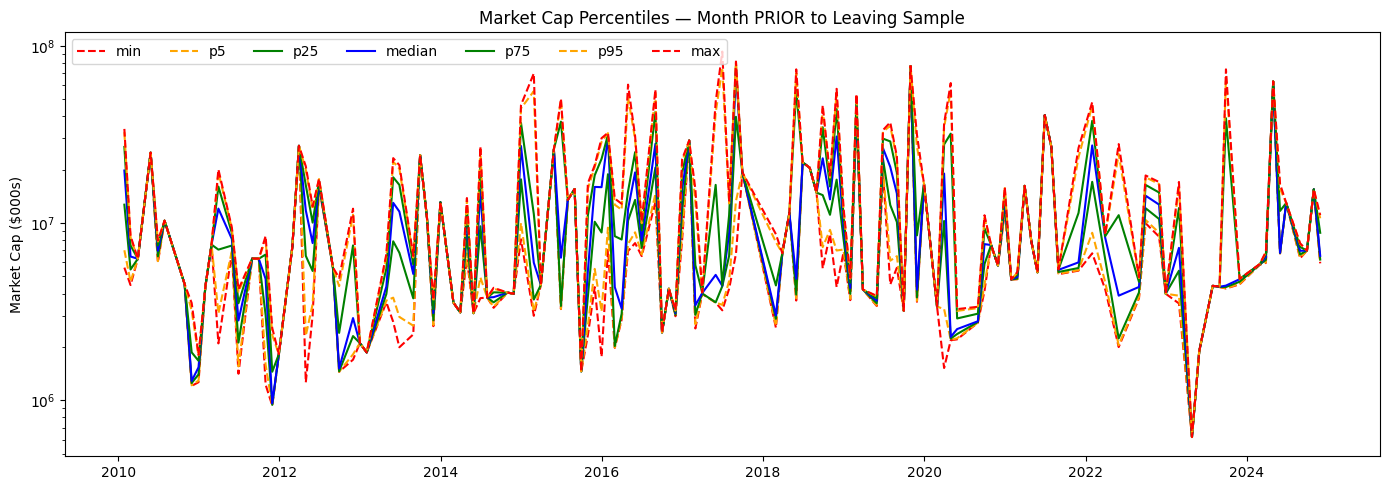

Median of each percentile (leavers):


min       4.504323e+06
p5        4.827668e+06
p25       6.225747e+06
median    6.527089e+06
p75       8.787414e+06
p95       1.113388e+07
max       1.140592e+07
dtype: float64

In [35]:
# 5a — Leavers: month prior to leaving
dates_sorted = sorted(df['date'].unique())
companies_by_date = df.groupby('date')['permno'].apply(set).to_dict()

leavers = []
for i in range(len(dates_sorted)-1):
    t, t1 = dates_sorted[i], dates_sorted[i+1]
    leaving = companies_by_date[t] - companies_by_date[t1]
    if leaving:
        leavers.append(df[(df['date']==t) & (df['permno'].isin(leaving))])
leavers_df = pd.concat(leavers)
print(f"Total company-exit observations: {len(leavers_df)}")

lp = leavers_df.groupby('date').apply(calc_percentiles).dropna(how='all')
plot_percentiles(lp, 'Market Cap Percentiles — Month PRIOR to Leaving Sample', 'Market Cap ($000s)', True)
print("Median of each percentile (leavers):")
display(lp.median())

Total company-entry observations: 804


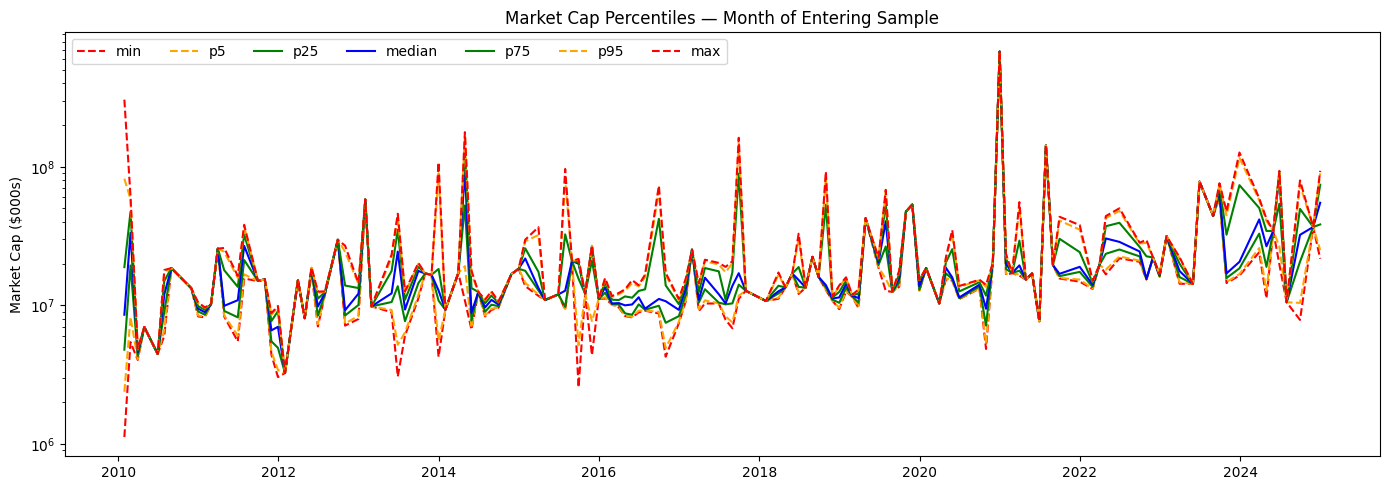

Median of each percentile (enterers):


min       1.248576e+07
p5        1.273659e+07
p25       1.359730e+07
median    1.425316e+07
p75       1.695235e+07
p95       1.709851e+07
max       1.773424e+07
dtype: float64

In [36]:
# 5b — Enterers: month of entering
enterers = [df[df['date']==dates_sorted[0]]]  # everyone on first date enters
for i in range(1, len(dates_sorted)):
    entering = companies_by_date[dates_sorted[i]] - companies_by_date[dates_sorted[i-1]]
    if entering:
        enterers.append(df[(df['date']==dates_sorted[i]) & (df['permno'].isin(entering))])
enterers_df = pd.concat(enterers)
print(f"Total company-entry observations: {len(enterers_df)}")

ep = enterers_df.groupby('date').apply(calc_percentiles).dropna(how='all')
plot_percentiles(ep, 'Market Cap Percentiles — Month of Entering Sample', 'Market Cap ($000s)', True)
print("Median of each percentile (enterers):")
display(ep.median())

Trailing returns (geometric):
1. Trailing twelve month return based on prc (we will refer to this PRC_Ret(T12))
2. Trailing twelve month return based on prices (we will refer to this Prices_Ret(T12))
3. Trailing twelve month return excluding the most recent trailing month based on prc. 
    - In other words, this eleven months of return starting from 12 months ago excluding the most recent month (we will to this as PRC_Ret(T12M1))
4. Trailing twelve month return excluding the most recent trailing month based on prices. 
    - In other words, this eleven months of return starting from 12 months ago excluding the most recent month (we will to this as Prices_Ret(T12M1))
5. The trailing one month return from exactly 12 months ago. In other words, if the EOM period is 2019-03 (March 2019), we want the return for the stock for 2018-03 (March 2018)
    - Do this based both on prc column and price based return. We will refer to this as PRC_Ret(T12_1M) and Prices_Ret(T12_1M)
7. Calculate the standard deviation of the monthly price_based returns used in calculating Prices_Ret(T12M1)
    - We call this Vol_Prices_Ret(T12M1)
    - Divide Prices_Ret(T12M1) / Vol_Prices_Ret(T12M1) We will call this SR_Prices_Ret(T12M1)

In [37]:
panel = build_full_panel(df)
print(panel.shape)
panel

(90525, 19)


,permno,date,price,shrout,prc,mcap,Price_Ret_T1,PRC_Ret_T12,Prices_Ret_T12,PRC_Ret_T12M1,Prices_Ret_T12M1,PRC_Ret_T12_1M,Prices_Ret_T12_1M,Vol_Prices_Ret_T12M1,SR_Prices_Ret_T12M1,PRC_Ret_F1M,PRC_Ret_F3M,PRC_Ret_F6M,log_mcap
0,10104,2010-01-29,23.06000,5011220,-0.057888,1.155587e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.068951,0.123917,0.029306,18.565289
1,10104,2010-02-26,24.65000,5015000,0.068951,1.236198e+08,0.068951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043002,-0.082612,-0.110203,18.632721
2,10104,2010-03-31,25.71000,5019091,0.043002,1.290408e+08,0.043002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008071,-0.163692,0.048572,18.675639
3,10104,2010-04-30,25.86750,5029523,0.008071,1.301012e+08,0.006126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.127477,-0.084179,0.140126,18.683823
4,10104,2010-05-28,22.57000,5026000,-0.127477,1.134368e+08,-0.127477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.049180,-0.030075,0.202849,18.546757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90520,93436,2024-08-30,214.11000,3194640,-0.077391,6.840044e+08,-0.077390,-0.170374,-0.170373,-0.100783,-0.100783,-0.034962,-0.034962,0.144055,-0.699612,0.221942,0.612069,NaN,20.343475
90521,93436,2024-09-30,261.63000,3207000,0.221942,8.390474e+08,0.221942,0.045600,0.045600,-0.144313,-0.144313,-0.030456,-0.030456,0.145742,-0.990195,-0.045025,0.543555,NaN,20.547778
90522,93436,2024-10-31,249.85001,3210060,-0.045025,8.020335e+08,-0.045025,0.244025,0.244025,0.302678,0.302679,-0.197346,-0.197346,0.144939,2.088316,0.381469,NaN,NaN,20.502661
90523,93436,2024-11-29,345.16000,3210060,0.381469,1.107984e+09,0.381469,0.437688,0.437687,0.040695,0.040695,0.195379,0.195379,0.136047,0.299123,0.170008,NaN,NaN,20.825808


**6.** For all of the variables you have calculated above, produce one time series graph for each variable, with each graph showing the Percentile Sets. 

In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output

Q6_VARS = [
    "Price_Ret_T1", "PRC_Ret_T12", "Prices_Ret_T12", "PRC_Ret_T12M1", "Prices_Ret_T12M1",
    "PRC_Ret_T12_1M", "Prices_Ret_T12_1M", "Vol_Prices_Ret_T12M1", "SR_Prices_Ret_T12M1",
    "PRC_Ret_F1M", "PRC_Ret_F3M", "PRC_Ret_F6M"
]

# Collect the percentiles and median info for each variable in advance
percentile_data = {}
median_rows = []
for var in Q6_VARS:
    if var not in panel.columns:
        continue
    pct_df = percentile_series_by_date(panel, var, "date")
    percentile_data[var] = pct_df
    med = median_of_percentiles(pct_df)
    median_rows.append({"variable": var, **med.to_dict()})

q6_table = pd.DataFrame(median_rows).set_index("variable")

def plot_percentiles(var):
    pct_df = percentile_data[var]
    fig, ax = plt.subplots(figsize=(12, 4))
    for col in PCT_LABELS:
        ax.plot(pct_df.index, pct_df[col], label=col, alpha=0.8)
    ax.set_title(var)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive widget
dropdown = widgets.Dropdown(
    options=[var for var in percentile_data.keys()],
    value=list(percentile_data.keys())[0],
    description='Variable:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def on_variable_change(change):
    with output:
        clear_output(wait=True)
        plot_percentiles(change['new'])

dropdown.observe(on_variable_change, names='value')

# Display the first plot and the dropdown widget
display(dropdown)
with output:
    plot_percentiles(dropdown.value)
display(output)

Dropdown(description='Variable:', options=('Price_Ret_T1', 'PRC_Ret_T12', 'Prices_Ret_T12', 'PRC_Ret_T12M1', '…

Output()

For each one of these also calculate the median value of the time series of each of the Percentile Sets values.

In [39]:
print("Median of each Percentile Set (over time), by variable:")
display(q6_table)

Median of each Percentile Set (over time), by variable:


,min,p5,p25,median,p75,p95,max
variable,,,,,,,
Price_Ret_T1,-0.376185,-0.089134,-0.022078,0.010877,0.046525,0.109271,0.361648
PRC_Ret_T12,-0.595384,-0.244292,-0.021343,0.122320,0.272831,0.533369,1.499190
Prices_Ret_T12,-0.745554,-0.301489,-0.055877,0.089438,0.241434,0.514467,3.957197
PRC_Ret_T12M1,-0.571966,-0.234087,-0.018947,0.110647,0.246444,0.509504,1.353259
Prices_Ret_T12M1,-0.748977,-0.276492,-0.049919,0.084931,0.223923,0.485717,3.660942
PRC_Ret_T12_1M,-0.236100,-0.084762,-0.021320,0.012519,0.048063,0.110931,0.310368
Prices_Ret_T12_1M,-0.356201,-0.086915,-0.022599,0.011054,0.044969,0.108322,0.336300
Vol_Prices_Ret_T12M1,0.023271,0.038241,0.055260,0.071222,0.091869,0.140991,0.926084
SR_Prices_Ret_T12M1,-6.420955,-3.050643,-0.697550,1.317398,3.821433,7.778726,16.787602


**7(a)** For the period November 2019 where the dependent variable is the one month forward return and the independent variable is PRC_Ret(T12M1). 

Report and interpret the coefficient.

In [40]:
# Cross-section as of Oct 2019 EOM; y = one-month forward return (Oct 31–Nov 30 2019)
oct = panel[panel["date"].dt.to_period("M") == "2019-10"].dropna(subset=["PRC_Ret_F1M", "PRC_Ret_T12M1"])
r = cross_sectional_ols(oct["PRC_Ret_F1M"], oct[["PRC_Ret_T12M1"]])
coef_7a = r["coef"].iloc[0]
print("Coefficient (PRC_Ret_T12M1):", round(coef_7a, 6), "| R²:", round(r["r_squared"], 4))

Coefficient (PRC_Ret_T12M1): -0.06248 | R²: 0.0532


**7(b)** Run the same cross-sectional regressions for the entire sample. Plot the time series of the coefficients. Calculate the statistical significance of the sample regression.

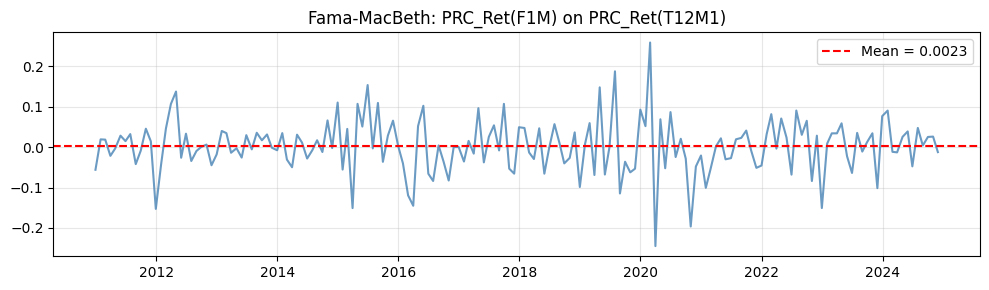

Mean coef: 0.002252 | t = 0.4395 | p = 0.6609


In [41]:
valid = panel.dropna(subset=["PRC_Ret_F1M", "PRC_Ret_T12M1"])
coef_7b = run_fama_macbeth(valid, "PRC_Ret_F1M", ["PRC_Ret_T12M1"])
inf_7b = fama_macbeth_inference(coef_7b["PRC_Ret_T12M1"])
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(coef_7b.index, coef_7b["PRC_Ret_T12M1"], color="steelblue", alpha=0.8)
ax.axhline(inf_7b["mean"], color="red", linestyle="--", label=f"Mean = {inf_7b['mean']:.4f}")
ax.set_title("Fama-MacBeth: PRC_Ret(F1M) on PRC_Ret(T12M1)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Mean coef:", round(inf_7b["mean"], 6), "| t =", round(inf_7b["t_stat"], 4), "| p =", round(inf_7b["p_value"], 4))

**7(c)** Interpret your result, both economically and statistically. 

Momentum [-12,-1] as strategy? Explain to a layperson. 

Consistency across time?

Notable periods?

**7(d)** Peterson Ch.2: hit rates, draw-downs, max draw-down, sortino ratio, etc. Interpretation of single coefficient and of time-series of coefficients?

In [42]:
m7d = strategy_metrics(coef_7b["PRC_Ret_T12M1"])
print("Hit rate (frac months coef > 0):", round(m7d["hit_rate"], 4))
print("Max drawdown:", round(m7d["max_drawdown"], 4))
print("Sortino:", round(m7d["sortino"], 4))

Hit rate (frac months coef > 0): 0.5119
Max drawdown: -0.5708
Sortino: 0.034


=== Performance Measures (treating FMB coefficients as strategy returns) ===
Hit Rate:              51.2%
Avg Gain (pos months): 0.049664
Avg Loss (neg months): -0.047473
Slugging Ratio:        1.05
Max Drawdown (cum):    -0.6529 at 2021-12-31 00:00:00
Annualized Sharpe:     0.117
Annualized Sortino:    0.118


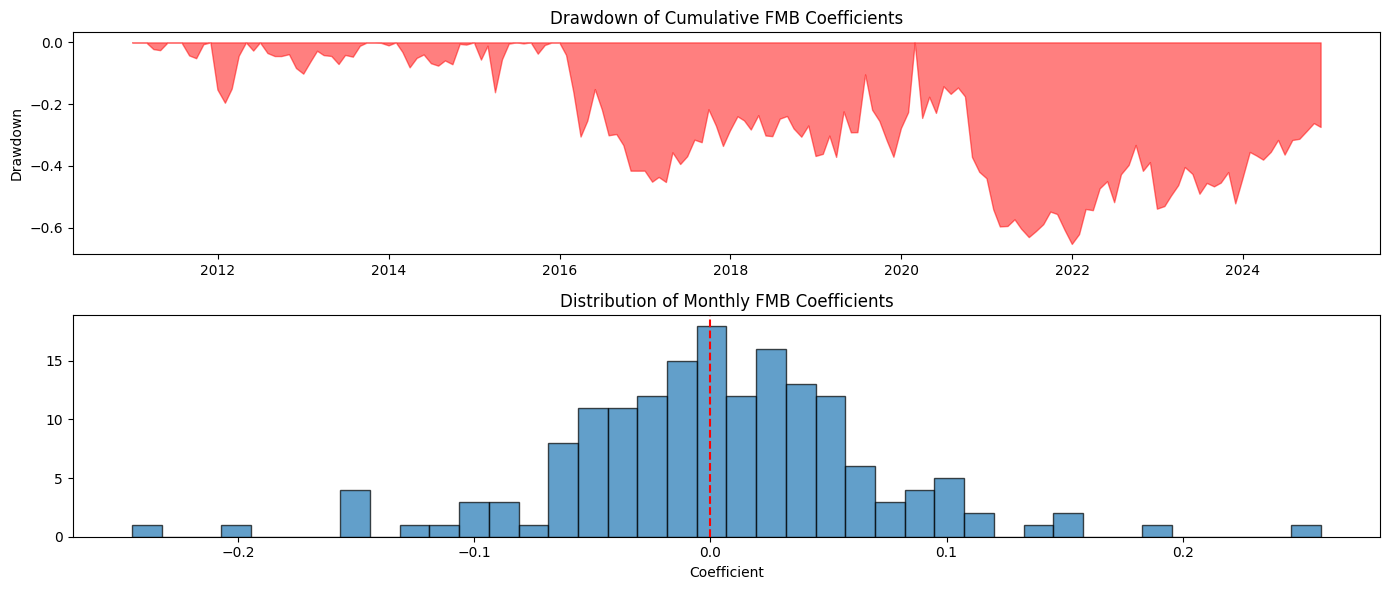

In [43]:
# Performance measures treating FMB coefficient series as strategy returns (Peterson-style)
coefs = coef_7b["PRC_Ret_T12M1"]

hit_rate = (coefs > 0).mean()
avg_gain = coefs[coefs > 0].mean() if (coefs > 0).any() else np.nan
avg_loss = coefs[coefs < 0].mean() if (coefs < 0).any() else np.nan
slugging = abs(avg_gain / avg_loss) if avg_loss != 0 and not np.isnan(avg_loss) else np.inf

# Drawdown on cumulative coefficient
cum = coefs.cumsum()
running_max = cum.cummax()
drawdown = cum - running_max
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

# Sortino ratio: mean / downside deviation, annualized
downside_dev = np.sqrt((coefs[coefs < 0]**2).mean()) if (coefs < 0).any() else np.nan
sortino = (coefs.mean() * 12) / (downside_dev * np.sqrt(12)) if (downside_dev is not None and not np.isnan(downside_dev) and downside_dev > 0) else np.nan
sharpe = (coefs.mean() * 12) / (coefs.std() * np.sqrt(12)) if coefs.std() > 0 else np.nan

print("=== Performance Measures (treating FMB coefficients as strategy returns) ===")
print(f"Hit Rate:              {hit_rate:.1%}")
print(f"Avg Gain (pos months): {avg_gain:.6f}")
print(f"Avg Loss (neg months): {avg_loss:.6f}")
print(f"Slugging Ratio:        {slugging:.2f}")
print(f"Max Drawdown (cum):    {max_dd:.4f} at {max_dd_date}")
print(f"Annualized Sharpe:     {sharpe:.3f}")
print(f"Annualized Sortino:    {sortino:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="red")
axes[0].set_title("Drawdown of Cumulative FMB Coefficients")
axes[0].set_ylabel("Drawdown")
axes[1].hist(coefs, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Distribution of Monthly FMB Coefficients")
axes[1].set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

**8(a)** Univariate Fama-MacBeth: dependent = one month forward returns.

Independent variables (one at a time):
- Price_Ret(T1)
- PRC
- PRC_Ret(T12) 
- Prices_Ret(T12)
- PRC_Ret(T12M1)
- Prices_Ret(T12M1)
- PRC_Ret(T12_1M)
- Prices_Ret(T12_1M)
- SR_Prices_Ret(T12M1)
    
Report as per 7(b). Discuss sign expectations and issues.

In [44]:
preds = ["Price_Ret_T1", "prc", "PRC_Ret_T12", "Prices_Ret_T12", "PRC_Ret_T12M1", "Prices_Ret_T12M1",
         "PRC_Ret_T12_1M", "Prices_Ret_T12_1M", "SR_Prices_Ret_T12M1"]
rows_8a = []
all_univar_cf = {}
for p in preds:
    if p not in panel.columns:
        continue
    v = panel.dropna(subset=["PRC_Ret_F1M", p])
    cf = run_fama_macbeth(v, "PRC_Ret_F1M", [p])
    if cf.empty:
        continue
    all_univar_cf[p] = cf
    inf = fama_macbeth_inference(cf[p])
    rows_8a.append({"predictor": p, "mean_coef": inf["mean"], "t_stat": inf["t_stat"], "p_value": inf["p_value"]})
display(pd.DataFrame(rows_8a))

,predictor,mean_coef,t_stat,p_value
0,Price_Ret_T1,0.001053,0.084225,0.932973
1,prc,-0.005330,-0.369210,0.712410
2,PRC_Ret_T12,0.001937,0.366899,0.714159
3,Prices_Ret_T12,-0.000765,-0.229453,0.818799
4,PRC_Ret_T12M1,0.002252,0.439516,0.660856
5,Prices_Ret_T12M1,0.000714,0.207082,0.836199
6,PRC_Ret_T12_1M,-0.003982,-0.367422,0.713772
7,Prices_Ret_T12_1M,-0.003712,-0.380474,0.704083
8,SR_Prices_Ret_T12M1,0.000104,0.299368,0.765033


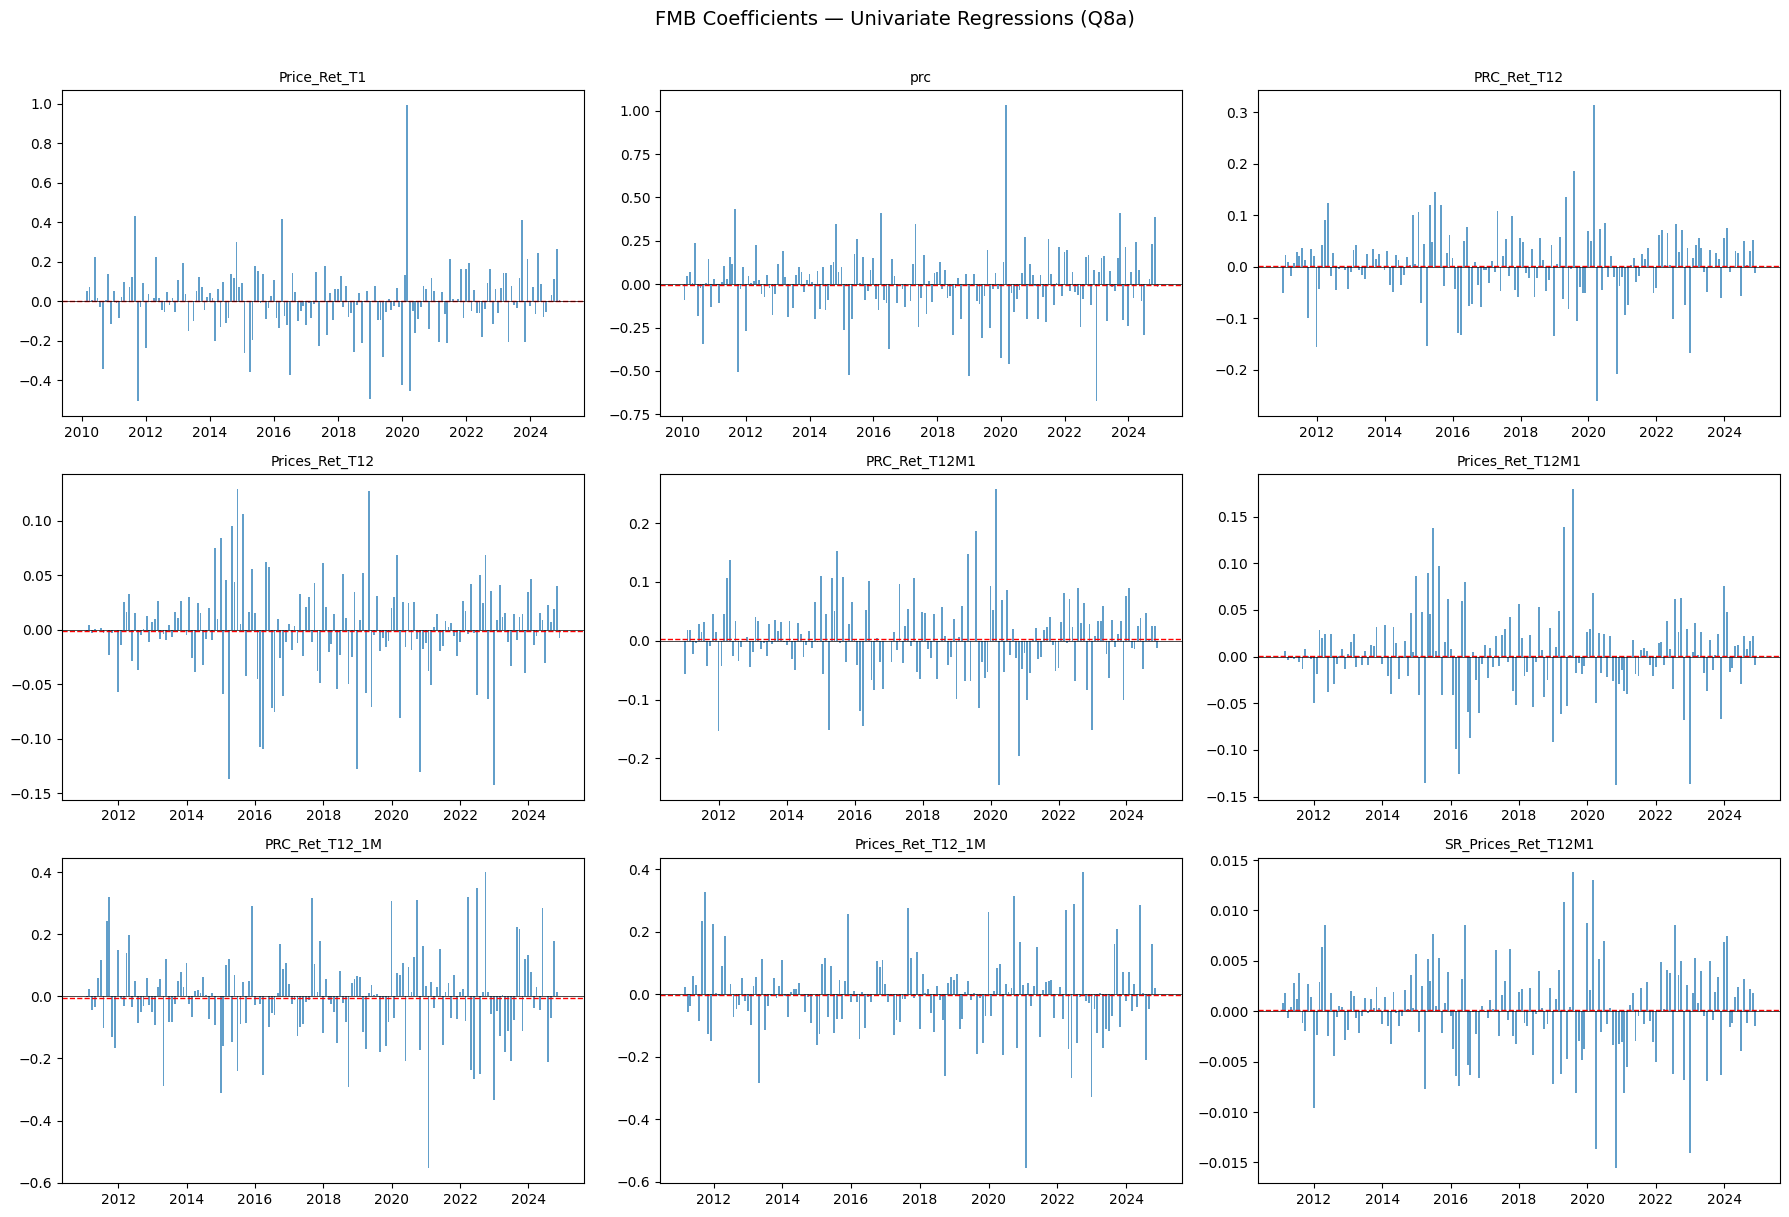

In [45]:
# Plot coefficient time series for each univariate predictor (Q8a)
plot_vars = [p for p in preds if p in all_univar_cf]
n_plot = len(plot_vars)
n_cols = 3
n_rows = (n_plot + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
for idx, var in enumerate(plot_vars):
    ax = axes[idx // n_cols][idx % n_cols]
    res = all_univar_cf[var]
    ax.bar(res.index, res[var], width=20, alpha=0.7)
    ax.axhline(res[var].mean(), color="red", ls="--", lw=1)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(var, fontsize=10)
for idx in range(n_plot, n_rows * n_cols):
    ax = axes[idx // n_cols][idx % n_cols]
    ax.set_visible(False)
plt.suptitle("FMB Coefficients — Univariate Regressions (Q8a)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**8(b)** Multivariate: same dependent as 8(a). 

Independent pairs: 
1. Price_Ret(T1) and Prices_Ret(T12M1)
2. PRC and PRC_Ret(T12M1)
3. PRC and Prices_Ret(T12)
4. PRC and SR_Prices_Ret(T12M1)

Report and discuss issues.

In [46]:
specs = [
    ["Price_Ret_T1", "Prices_Ret_T12M1"],
    ["prc", "PRC_Ret_T12M1"],
    ["prc", "Prices_Ret_T12"],
    ["prc", "SR_Prices_Ret_T12M1"],
]

results = []
for i, xcols in enumerate(specs):
    v = panel.dropna(subset=["PRC_Ret_F1M"] + xcols)
    cf = run_fama_macbeth(v, "PRC_Ret_F1M", xcols)
    if cf.empty:
        continue
    for col in xcols:
        inf = fama_macbeth_inference(cf[col])
        results.append({
            "Spec": f"{i+1}",
            "Predictor": col,
            "Mean Coef": inf["mean"],
            "t-stat": inf["t_stat"],
            "p-value": inf["p_value"]
        })


df_results = pd.DataFrame(results)
df_results = df_results[["Spec", "Predictor", "Mean Coef", "t-stat", "p-value"]]
display(df_results.style.format({
    "Mean Coef": "{:.4f}",
    "t-stat": "{:.4f}",
    "p-value": "{:.4f}"
}).set_caption("Fama-MacBeth Multivariate Results"))

,Spec,Predictor,Mean Coef,t-stat,p-value
0,1,Price_Ret_T1,0.0028,0.2179,0.8277
1,1,Prices_Ret_T12M1,0.0017,0.5199,0.6038
2,2,prc,-0.0011,-0.0794,0.9368
3,2,PRC_Ret_T12M1,0.0041,0.8751,0.3828
4,3,prc,-0.0012,-0.0859,0.9317
5,3,Prices_Ret_T12,0.0007,0.2489,0.8038
6,4,prc,-0.0002,-0.0135,0.9892
7,4,SR_Prices_Ret_T12M1,0.0002,0.6911,0.4904


**9.** Repeat 7(b) but using dependent variables PRC_Ret(F3M) and PRC_Ret(F6M)

Compare with 7(b). Potential econometric/statistical issues? How to correct?

In [47]:
results = []
for y_lab, y_col in [("F3M", "PRC_Ret_F3M"), ("F6M", "PRC_Ret_F6M")]:
    v = panel.dropna(subset=[y_col, "PRC_Ret_T12M1"])
    cf = run_fama_macbeth(v, y_col, ["PRC_Ret_T12M1"])
    if cf.empty:
        continue
    inf = fama_macbeth_inference(cf["PRC_Ret_T12M1"])
    nw = newey_west_t_stat(cf["PRC_Ret_T12M1"])
    results.append({
        "Horizon": y_lab,
        "Mean Coef": inf["mean"],
        "Std t-stat": inf["t_stat"],
        "Std p-value": inf["p_value"],
        "NW t-stat": nw["t_stat"],
        "NW p-value": nw["p_value"]
    })

df_results = pd.DataFrame(results)
display(df_results.style.format({
    "Mean Coef": "{:.4f}",
    "Std t-stat": "{:.4f}",
    "Std p-value": "{:.4f}",
    "NW t-stat": "{:.4f}",
    "NW p-value": "{:.4f}"
}).set_caption("Fama-MacBeth Regressions for F3M and F6M (with Newey-West)"))

,Horizon,Mean Coef,Std t-stat,Std p-value,NW t-stat,NW p-value
0,F3M,0.0056,0.7010,0.4843,0.4654,0.6423
1,F6M,0.0107,0.8962,0.3715,0.4515,0.6522


**10.** Repeat 7(b) with weight = log(market cap). Compare with original. Why this weighting? What issues?

In [48]:
# Prepare data: drop any rows missing required columns
v = panel.dropna(subset=["PRC_Ret_F1M", "PRC_Ret_T12M1", "log_mcap"])

# Run Fama-MacBeth using log(mcap) as regression weights
cf_w = run_fama_macbeth(
    v,
    "PRC_Ret_F1M",
    ["PRC_Ret_T12M1"],
    weight_col="log_mcap"
)

# Extract inference statistics for the weighted regression
inf_w = fama_macbeth_inference(cf_w["PRC_Ret_T12M1"])

# Build a tidy DataFrame with both results for nicer display
comp_df = pd.DataFrame({
    "Type": ["Unweighted [from 7(b)]", "Weighted (log mcap)"],
    "Mean": [inf_7b['mean'], inf_w['mean']],
    "t-stat": [inf_7b['t_stat'], inf_w['t_stat']]
}).set_index("Type")

display(comp_df.style.format({"Mean": "{:.6f}", "t-stat": "{:.4f}"}).set_caption("Comparison: Unweighted vs Log(Mcap)-Weighted Fama-MacBeth Results"))

,Mean,t-stat
Type,,
Unweighted [from 7(b)],0.002252,0.4395
Weighted (log mcap),0.002424,0.4805


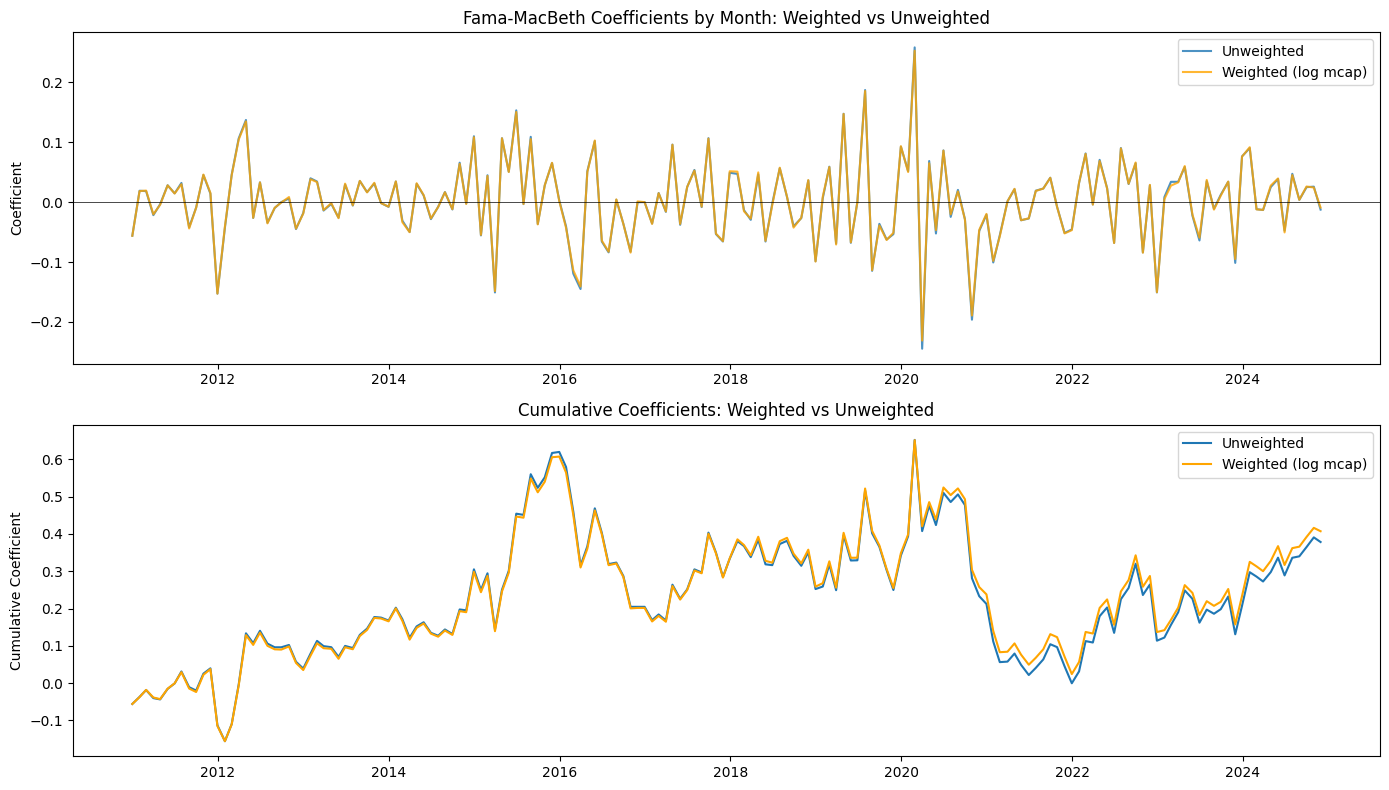

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Align unweighted (from Q7b) and weighted (log mcap) coefficient series by date
common_idx = coef_7b.index.intersection(cf_w.index)
u_ser = coef_7b.loc[common_idx, 'PRC_Ret_T12M1']
w_ser = cf_w.loc[common_idx, 'PRC_Ret_T12M1']
axes[0].plot(common_idx, u_ser, alpha=0.8, label='Unweighted')
axes[0].plot(common_idx, w_ser, alpha=0.8, label='Weighted (log mcap)', color='orange')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Fama-MacBeth Coefficients by Month: Weighted vs Unweighted')
axes[0].set_ylabel('Coefficient')
axes[0].legend()

axes[1].plot(common_idx, u_ser.cumsum(), label='Unweighted')
axes[1].plot(common_idx, w_ser.cumsum(), label='Weighted (log mcap)', color='orange')
axes[1].set_title('Cumulative Coefficients: Weighted vs Unweighted')
axes[1].set_ylabel('Cumulative Coefficient')
axes[1].legend()

plt.tight_layout()
plt.show()